### Unsloth


In [1]:
import os
import json

# Load configuration
config_path = "../configs/hyperparameters.json"
with open(config_path, "r") as f:
    config = json.load(f)

os.environ["CUDA_VISIBLE_DEVICES"] = config["environment"]["cuda_visible_devices"]


In [2]:
import torch
print(f"Có GPU không? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch không tìm thấy GPU.")

Có GPU không? True
Tên GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
from unsloth import FastLanguageModel
import torch
from dotenv import load_dotenv

load_dotenv()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = config["model"]["model_name"],
    max_seq_length = config["model"]["max_seq_length"],
    full_finetuning = config["model"]["full_finetuning"],
    token = os.getenv("HF_TOKEN")
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/zeus/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: You selected full finetuning support, but 4bit / 8bit is enabled - disabling LoRA / QLoRA.
==((====))==  Unsloth 2026.5.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using bfloat16 full finetuning which cuts memory usage by 50%.
To enable float32 training, use `float32_mixed_precision = True` during FastLanguageModel.from_pretrained


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 1047.82it/s]


unsloth/Qwen3-1.7B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [4]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = config["dataset"]["chat_template"],
)

In [5]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("json", data_files=config["dataset"]["train_file"]).shuffle(seed=42)

# By default, it loads into a DatasetDict under the "train" split
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['amr', 'sentence', 'system_prompt', 'reasoning'],
        num_rows: 5792
    })
})


We now convert the reasoning dataset into conversational format:

In [6]:
import penman

def remove_wiki(amr_text):
    triples = penman.decode(amr_text).triples
    triples = [x for x in triples if x[1] != ":wiki"]
    return penman.encode(penman.Graph(triples))

def flat_amr(amr_text):
    graph = penman.decode(amr_text)
    return penman.encode(graph, indent=0, compact=True).replace("\n", " ")

# Test the function
sample = dataset["train"][1]["amr"]
print("Original: \n",sample)
amr_removed_wiki = remove_wiki(sample)
print("Removed wiki: \n",amr_removed_wiki)
amr_flated = flat_amr(sample)
print("Flated: \n",amr_flated)

Original: 
 (p / possible-01
   :polarity -
   :ARG1 (g / get-01
            :ARG0 (w / we)
            :ARG1 (a / agree-01
                     :ARG0 (p2 / political-party
                               :quant 2.5)
                     :ARG1 (p3 / principle
                               :mod (f / fundamental)
                               :mod (e / economy)))
            :mod (e2 / even)))
Removed wiki: 
 (p / possible-01
   :polarity -
   :ARG1 (g / get-01
            :ARG0 (w / we)
            :ARG1 (a / agree-01
                     :ARG0 (p2 / political-party
                               :quant 2.5)
                     :ARG1 (p3 / principle
                               :mod (f / fundamental)
                               :mod (e / economy)))
            :mod (e2 / even)))
Flated: 
 (p / possible-01 :polarity - :ARG1 (g / get-01 :ARG0 (w / we) :ARG1 (a / agree-01 :ARG0 (p2 / political-party :quant 2.5) :ARG1 (p3 / principle :mod (f / fundamental) :mod (e / economy))) :mod (

In [7]:
def generate_conversation(examples):
    inputs  = examples["sentence"]
    reasonings = examples["reasoning"]
    ouputs = examples["amr"]
    system_prompts = examples["system_prompt"]
    
    conversations = []
    for input_text, reasoning, output, system_prompt in zip(inputs, reasonings, ouputs, system_prompts):
        output = remove_wiki(output)
        output = flat_amr(output)
        enable_thinking = config["inference"]["enable_thinking"]
        if enable_thinking:
            conversations.append([
                {"role" : "system",     "content" : system_prompt},
                {"role" : "user",      "content" : f"Convert the following English sentence into its Abstract Meaning Representation (AMR):\n\n<sentence>{input_text}</sentence>"},
                {"role" : "assistant", "content" : f"<think>\n{reasoning}\n</think>\n\n<amr>\n{output}\n</amr>"},
            ])
        else:
            conversations.append([
                {"role" : "system",     "content" : system_prompt},
                {"role" : "user",      "content" : f"Convert the following English sentence into its Abstract Meaning Representation (AMR):\n\n<sentence>{input_text}</sentence>"},
                {"role" : "assistant", "content" : f"<think>\n\n</think>\n\n<amr>\n{output}\n</amr>"},
            ])
            
    return { "conversations": conversations, }

# Deduplicate input sentences
seen_texts = set()
def filter_duplicates(example):
    if example["sentence"] in seen_texts:
        return False
    seen_texts.add(example["sentence"])
    return True

dataset = dataset.filter(filter_duplicates)
dataset = dataset.map(generate_conversation, batched = True)

Map: 100%|██████████| 5791/5791 [00:02<00:00, 2548.39 examples/s]


We now have to apply the chat template for `Qwen-3` onto the conversations, and save it to `text`.

In [8]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
   return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

Map: 100%|██████████| 5791/5791 [00:00<00:00, 7740.44 examples/s]


Map: 100%|██████████| 5791/5791 [00:16<00:00, 340.68 examples/s]


Tổng số mẫu: 5791
Số token trung bình: 2984.91
Số token trung vị: 2524.00
Số token min: 315
Số token max: 18633
Độ lệch chuẩn: 1848.22

Percentiles:
25%: 1746
50%: 2524
75%: 3717
90%: 5294
95%: 6522
99%: 9474


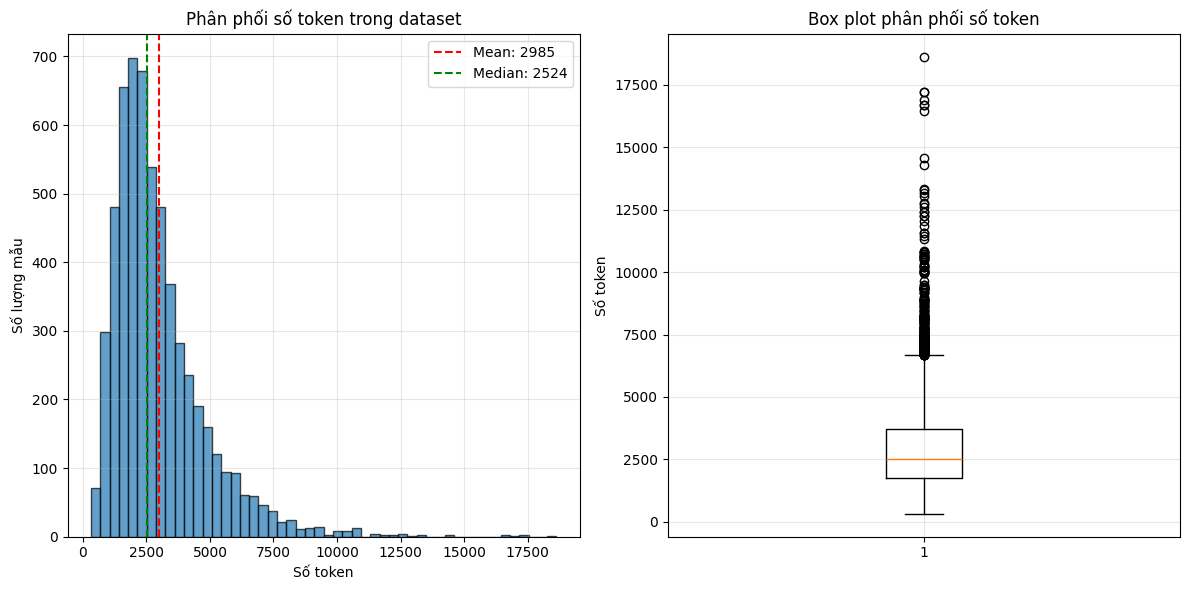

In [9]:
# Phân tích phân phối số token trong dataset
import numpy as np
import matplotlib.pyplot as plt

def count_tokens(examples):
    texts = examples["text"]
    token_counts = []
    for text in texts:
        tokens = tokenizer(text, truncation=False)["input_ids"]
        token_counts.append(len(tokens))
    return {"token_count": token_counts}

# Áp dụng hàm đếm token
dataset_with_counts = dataset["train"].map(count_tokens, batched=True)

# Lấy danh sách số token
token_counts = dataset_with_counts["token_count"]

# Thống kê cơ bản
print(f"Tổng số mẫu: {len(token_counts)}")
print(f"Số token trung bình: {np.mean(token_counts):.2f}")
print(f"Số token trung vị: {np.median(token_counts):.2f}")
print(f"Số token min: {np.min(token_counts)}")
print(f"Số token max: {np.max(token_counts)}")
print(f"Độ lệch chuẩn: {np.std(token_counts):.2f}")
print(f"\nPercentiles:")
print(f"25%: {np.percentile(token_counts, 25):.0f}")
print(f"50%: {np.percentile(token_counts, 50):.0f}")
print(f"75%: {np.percentile(token_counts, 75):.0f}")
print(f"90%: {np.percentile(token_counts, 90):.0f}")
print(f"95%: {np.percentile(token_counts, 95):.0f}")
print(f"99%: {np.percentile(token_counts, 99):.0f}")

# Vẽ histogram
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(token_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Số token')
plt.ylabel('Số lượng mẫu')
plt.title('Phân phối số token trong dataset')
plt.axvline(np.mean(token_counts), color='r', linestyle='--', label=f'Mean: {np.mean(token_counts):.0f}')
plt.axvline(np.median(token_counts), color='g', linestyle='--', label=f'Median: {np.median(token_counts):.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(token_counts, vert=True)
plt.ylabel('Số token')
plt.title('Box plot phân phối số token')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Let's see how the chat template did!


In [10]:
dataset["train"][100]['text']

'<|im_start|>system\nYou are an expert in Abstract Meaning Representation (AMR).\n\n## Internal Knowledge\nYou have been provided pre-analyzed hints for this sentence.\nTreat them as verified facts — they are correct, but they are incomplete.\nYour job is to use them as anchors, not as a recipe.\n\n<knowledge>\n{\n    "root": "have-condition-91",\n    "frames": [\n        {\n            "frame": "have-condition-91",\n            "meaning": null,\n            "used_args": [\n                "ARG1",\n                "ARG2"\n            ],\n            "used_arguments": {\n                "ARG1": "main event",\n                "ARG2": "condition"\n            },\n            "arguments": {\n                "ARG1": "main event",\n                "ARG2": "condition"\n            }\n        },\n        {\n            "frame": "get-01",\n            "meaning": "transfer of goods, acquire",\n            "used_args": [\n                "ARG0",\n                "ARG1"\n            ],\n          

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [11]:
config['model']['model_name'].split("/")[-1].lower()

'qwen3-1.7b'

In [12]:
import os
import wandb
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d-%H%M")
tempt= config['model']['model_name'].split("/")[-1].lower()
run_name = f"{tempt}-amr-{timestamp}"
api_key = os.getenv("WANDB_API_KEY")
wandb.login(key=api_key)

run = wandb.init(
    project=f"sft-llm-amr-parsing", 
    name=run_name
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /teamspace/studios/this_studio/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Currently logged in as: 52100882 (mai-duy-edu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


In [13]:
from trl import SFTTrainer, SFTConfig

training_config = config["training"]

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset["train"],
    eval_dataset = None,
    args = SFTConfig(
        dataset_text_field = training_config["dataset_text_field"],
        packing = training_config["packing"],
        per_device_train_batch_size = training_config["per_device_train_batch_size"],
        gradient_accumulation_steps = training_config["gradient_accumulation_steps"],
        warmup_ratio = training_config["warmup_ratio"],
        num_train_epochs = training_config["num_train_epochs"],
        learning_rate = training_config["learning_rate"],
        logging_steps = training_config["logging_steps"],
        optim = training_config["optim"],
        weight_decay = training_config["weight_decay"],
        lr_scheduler_type = training_config["lr_scheduler_type"],
        report_to = training_config["report_to"],
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Unsloth: Tokenizing ["text"] (num_proc=52): 100%|██████████| 5791/5791 [00:34<00:00, 166.28 examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetunes!

In [14]:
from unsloth.chat_templates import train_on_responses_only

response_config = config["train_on_responses"]

trainer = train_on_responses_only(
    trainer,
    instruction_part = response_config["instruction_part"],
    response_part = response_config["response_part"],
)

Filter (num_proc=52): 100%|██████████| 5791/5791 [00:01<00:00, 4807.88 examples/s]


Let's verify masking the instruction part is done! Let's print the 100th row again.

In [15]:
tokenizer.decode(trainer.train_dataset[100]["input_ids"])

'<|im_start|>system\nYou are an expert in Abstract Meaning Representation (AMR).\n\n## Internal Knowledge\nYou have been provided pre-analyzed hints for this sentence.\nTreat them as verified facts — they are correct, but they are incomplete.\nYour job is to use them as anchors, not as a recipe.\n\n<knowledge>\n{\n    "root": "have-condition-91",\n    "frames": [\n        {\n            "frame": "have-condition-91",\n            "meaning": null,\n            "used_args": [\n                "ARG1",\n                "ARG2"\n            ],\n            "used_arguments": {\n                "ARG1": "main event",\n                "ARG2": "condition"\n            },\n            "arguments": {\n                "ARG1": "main event",\n                "ARG2": "condition"\n            }\n        },\n        {\n            "frame": "get-01",\n            "meaning": "transfer of goods, acquire",\n            "used_args": [\n                "ARG0",\n                "ARG1"\n            ],\n          

Now let's print the masked out example - you should see only the answer is present:

In [17]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA RTX PRO 6000 Blackwell Server Edition. Max memory = 94.971 GB.
3.236 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [18]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,791 | Num Epochs = 1 | Total steps = 181
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 1,720,574,976 of 1,720,574,976 (100.00% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
30,1.061026
60,0.824386
90,0.777557
120,0.756299
150,0.756252
180,0.749037


In [ ]:

# Push full model lên HF Hub
model_id = f"viamr-project/{run_name}"
model.push_to_hub(model_id, token = os.getenv("HF_TOKEN"))
tokenizer.push_to_hub(model_id, token = os.getenv("HF_TOKEN"))

print(f"✓ Full model đã được push lên: {run_name}")
print("Model này có thể dùng trực tiếp với vLLM!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.51s/it]
Processing Files (1 / 1): 100%|██████████| 3.44GB / 3.44GB,  304MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Restored added_tokens_decoder metadata in /tmp/tmptlt5zwwt/tokenizer_config.json.


Saved model to https://huggingface.co/viamr-project/qwen3-1.7b-amr-20260512-1445


Processing Files (1 / 1): 100%|██████████| 11.4MB / 11.4MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


✓ Full model đã được push lên: qwen3-1.7b-amr-20260512-1445
Model này có thể dùng trực tiếp với vLLM!
